<a href="https://colab.research.google.com/github/Salma19mostafa/Salma19mostafa/blob/main/My_eighth_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

Saving archive(3).zip to archive(3).zip
User uploaded file "archive(3).zip" with length 2043633 bytes


In [2]:
import zipfile
import os
import pandas as pd

zip_file_path = '/content/archive(3).zip'

# Create a directory to extract the files into
extraction_path = '/content/extracted_data'
os.makedirs(extraction_path, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

print(f"Files extracted to: {extraction_path}")
print("Extracted files:")
for root, dirs, files in os.walk(extraction_path):
    for file in files:
        print(os.path.join(root, file))

Files extracted to: /content/extracted_data
Extracted files:
/content/extracted_data/amazon.csv


In [3]:
# Assuming 'amazon.csv' is the file we need, based on the kernel state.
# If there are multiple CSVs, this might need adjustment.
csv_file_path = os.path.join(extraction_path, 'amazon.csv')

# Load the CSV file into a pandas DataFrame
df = pd.read_csv(csv_file_path)

# Display the first 5 rows of the DataFrame
display(df.head())

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

amazon = pd.read_csv(csv_file_path)

amazon.head()
amazon.columns
len(amazon)
amazon.isnull().sum()

,0
product_id,0
product_name,0
category,0
discounted_price,0
actual_price,0
discount_percentage,0
rating,0
rating_count,2
about_product,0
user_id,0


In [8]:
# Convert discounted_price to a numeric type
amazon['discounted_price_numeric'] = amazon['discounted_price'].str.replace('₹', '').str.replace(',', '').astype(float)

# Top products by total discounted price
print("Top products by total discounted price:")
print(amazon.groupby("product_name")["discounted_price_numeric"].sum().sort_values(ascending=False).head())

# Note: Columns for 'Region' and 'Month' are not available in this dataset.

Top products by total discounted price:
product_name
Sony Bravia 164 cm (65 inches) 4K Ultra HD Smart LED Google TV KD-65X74K (Black)                 77990.0
OnePlus 163.8 cm (65 inches) U Series 4K LED Smart Android TV 65U1S (Black)                      61999.0
VU 164 cm (65 inches) The GloLED Series 4K Smart LED Google TV 65GloLED (Grey)                   54990.0
LG 139 cm (55 inches) 4K Ultra HD Smart LED TV 55UQ7500PSF (Ceramic Black)                       47990.0
Samsung 138 cm (55 inches) Crystal 4K Neo Series Ultra HD Smart LED TV UA55AUE65AKXXL (Black)    47990.0
Name: discounted_price_numeric, dtype: float64


In [10]:
highest = amazon.loc[amazon["discounted_price_numeric"].idxmax()]
lowest = amazon.loc[amazon["discounted_price_numeric"].idxmin()]

print("Highest:", highest["product_name"], highest["discounted_price_numeric"])
print("Lowest:", lowest["product_name"], lowest["discounted_price_numeric"])

Highest: Sony Bravia 164 cm (65 inches) 4K Ultra HD Smart LED Google TV KD-65X74K (Black) 77990.0
Lowest: GIZGA essentials Universal Silicone Keyboard Protector Skin for 15.6-inches Laptop (5 x 6 x 3 inches) 39.0


/tmp/ipykernel_1170/2201004972.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="discounted_price_numeric", y="product_name", data=ranked.head(10), palette="viridis")


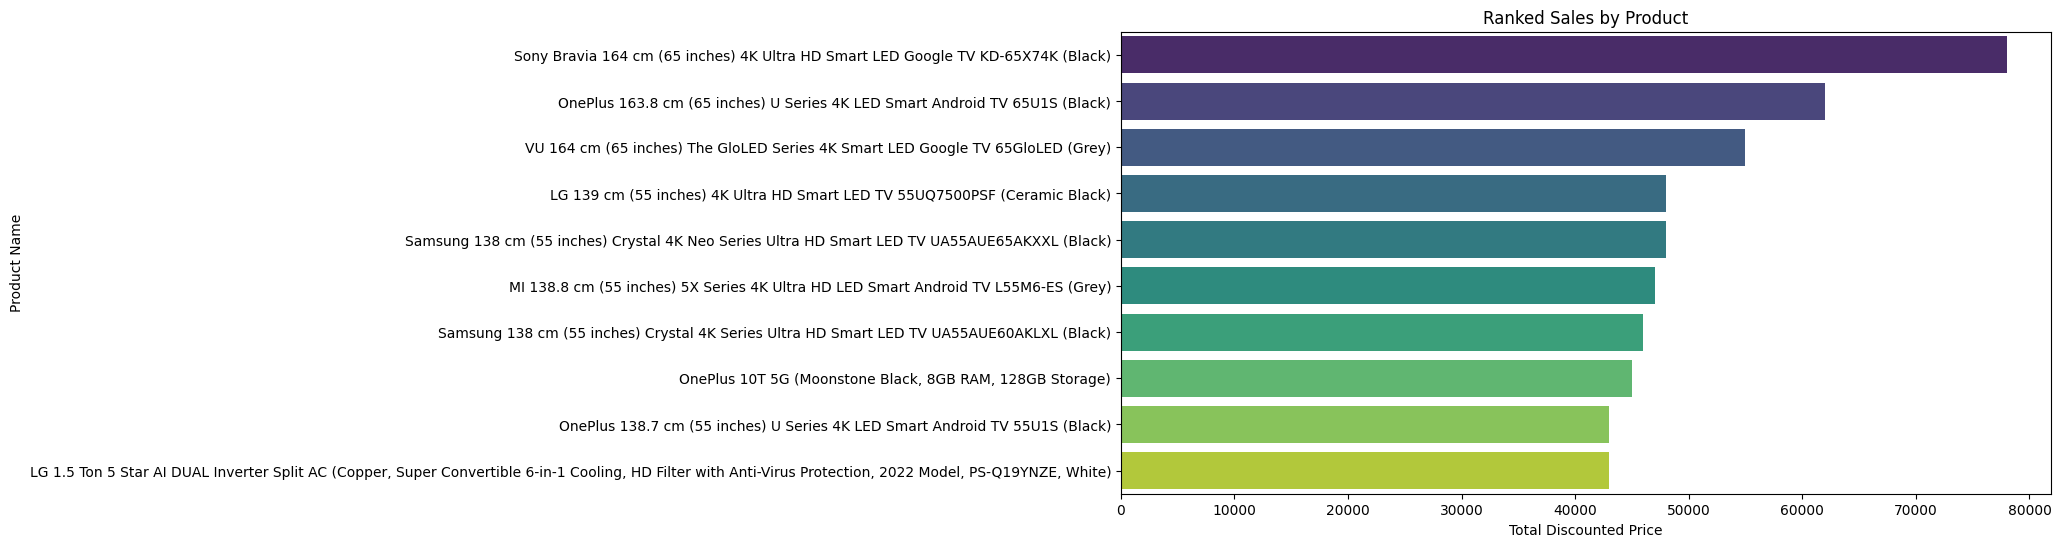

In [12]:
ranked = amazon.groupby("product_name")["discounted_price_numeric"].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12,6))
sns.barplot(x="discounted_price_numeric", y="product_name", data=ranked.head(10), palette="viridis")
plt.title("Ranked Sales by Product")
plt.xlabel("Total Discounted Price")
plt.ylabel("Product Name")
plt.show()

This bar chart shows the top 10 products that generated the highest total discounted sales revenue. You can see that certain high-value electronics, like Sony and OnePlus TVs, are at the top, contributing significantly more than other products.

Insight: A small number of high-value products, particularly electronics, are driving a disproportionately large amount of the total discounted sales.

Recommendation: Capitalize on the strong performance of these top products by prioritizing their marketing, inventory, and promotional strategies to maximize overall revenue.